In [31]:
import os
import numpy as np
import pandas as pd
import time
from datetime import datetime
import pyswarms as ps
from pyswarms.single.global_best import GlobalBestPSO
from pyswarms.utils.functions import single_obj as fx
from pyswarms.utils.plotters import plot_cost_history, plot_contour, plot_surface
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from utilities.utils import HelperFunctions, SSPModelForCalibration, ErrorFunctions
from utilities.diff_reports_v2 import DiffReportUtils
import logging
from sisepuede.manager.sisepuede_examples import SISEPUEDEExamples
from ssp_transformations_handler.GeneralUtils import GeneralUtils
import json


In [32]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Record the start time
start_time = time.time()

# Initialize helper functions
helper_functions = HelperFunctions()
gu = GeneralUtils()

In [34]:
# Paths
SRC_FILE_PATH = os.getcwd()
build_path = lambda PATH: os.path.abspath(os.path.join(*PATH))
DATA_PATH = build_path([SRC_FILE_PATH, "..", "data"])
OUTPUT_PATH = build_path([SRC_FILE_PATH, "..", "output"])
MISC_FILES_PATH = build_path([SRC_FILE_PATH, 'misc'])
VAR_MAPPING_FILES_PATH = build_path([MISC_FILES_PATH, 'var_mapping'])
SECTORAL_REPORT_PATH = build_path([MISC_FILES_PATH, 'sectoral_reports'])
SECTORAL_REPORT_MAPPING_PATH = build_path([MISC_FILES_PATH, 'sectoral_report_mapping'])
OPT_CONFIG_FILES_PATH = build_path([SRC_FILE_PATH, 'config'])
OPT_OUTPUT_PATH = build_path([SRC_FILE_PATH,"..", "output"])

In [35]:
# Make sure the output directory exists
os.makedirs(OPT_OUTPUT_PATH, exist_ok=True)

In [36]:
# Get important params from the YAML file
try:
    yaml_file = 'uganda_opt_config.yaml'
except IndexError:
    raise ValueError("YAML configuration file must be provided as a command-line argument.")

param_dict = helper_functions.get_parameters_from_yaml(build_path([OPT_CONFIG_FILES_PATH, yaml_file]))

target_region = param_dict['target_region']
iso_alpha_3 = param_dict['iso_alpha_3']
stressed_variables_report_version = param_dict['stressed_variables_report_version']
input_data_file_to_calibrate = param_dict["input_data_file_to_calibrate"]
detailed_diff_report_flag = param_dict['detailed_diff_report_flag']
energy_model_flag = param_dict['energy_model_flag']
emission_targets_file = param_dict['emission_targets_file']
sim_init_year = param_dict['sim_init_year']
comparison_init_year = param_dict['comparison_init_year']
comparison_year = param_dict['comparison_year']
subsector_to_calibrate = param_dict['subsector_to_calibrate']
error_type = param_dict['error_type']
weight_type = param_dict['weight_type']
unique_id = datetime.now().strftime("%Y%m%d%H%M%S")
swarm_size = param_dict['swarmsize']
maxiter = param_dict['maxiter']
# input_rows = param_dict['input_rows']
ssp_edgar_cw_file_name = param_dict['ssp_edgar_cw']

logging.info(f"Starting optimization for {target_region} (ISO code: {iso_alpha_3})")
# logging.info(f"Input rows: {input_rows}")
logging.info(f"Stressed variables report version: {stressed_variables_report_version}")
logging.info(f"Input data file to calibrate: {input_data_file_to_calibrate}")
logging.info(f"Energy model flag: {energy_model_flag}")
logging.info(f"Emission targets file: {emission_targets_file}")
logging.info(f"Simulation initial year: {sim_init_year}")
logging.info(f"Comparison initial year: {comparison_init_year}")
logging.info(f"Comparison year: {comparison_year}")
logging.info(f"Subsector to calibrate: {subsector_to_calibrate}")
logging.info(f"Error type: {error_type}")
logging.info(f"Weight type: {weight_type}")
logging.info(f"Unique ID: {unique_id}")
logging.info(f"Swarm size: {swarm_size}")
logging.info(f"Max iterations: {maxiter}")
logging.info(f"Detailed diff report flag: {detailed_diff_report_flag}")
logging.info(f"SSP-EDGAR crosswalk file: {ssp_edgar_cw_file_name}")

2025-07-31 14:15:26,182 - root - INFO - Starting optimization for uganda (ISO code: UGA)
2025-07-31 14:15:26,184 - root - INFO - Stressed variables report version: stressed_variables_report_2025_06_06.xlsx
2025-07-31 14:15:26,184 - root - INFO - Input data file to calibrate: new_uganda_inputs.csv


2025-07-31 14:15:26,185 - root - INFO - Energy model flag: False
2025-07-31 14:15:26,186 - root - INFO - Emission targets file: emission_targets_uganda.csv
2025-07-31 14:15:26,188 - root - INFO - Simulation initial year: 2015
2025-07-31 14:15:26,189 - root - INFO - Comparison initial year: 2020
2025-07-31 14:15:26,190 - root - INFO - Comparison year: 2022
2025-07-31 14:15:26,191 - root - INFO - Subsector to calibrate: None
2025-07-31 14:15:26,192 - root - INFO - Error type: mse
2025-07-31 14:15:26,193 - root - INFO - Weight type: norm_weight
2025-07-31 14:15:26,194 - root - INFO - Unique ID: 20250731141526
2025-07-31 14:15:26,195 - root - INFO - Swarm size: 2
2025-07-31 14:15:26,196 - root - INFO - Max iterations: 2
2025-07-31 14:15:26,198 - root - INFO - Detailed diff report flag: True
2025-07-31 14:15:26,200 - root - INFO - SSP-EDGAR crosswalk file: sisepuede_edgar_active_crosswalk.csv


In [37]:
# Make sure the output directory exists
os.makedirs(OPT_OUTPUT_PATH, exist_ok=True)

# Make sure pso output directories exist
PSO_OUTPUT_PATH = build_path([OUTPUT_PATH, target_region])
os.makedirs(PSO_OUTPUT_PATH, exist_ok=True)

# Create the output directory for the PSO results using the unique ID
RUN_OUTPUT_DIR = os.path.join(PSO_OUTPUT_PATH, unique_id)
os.makedirs(RUN_OUTPUT_DIR, exist_ok=True)

In [38]:
# Save the config file to the output directory
config_file_name = f"{unique_id}_config.yaml"
config_file_output_path = os.path.join(RUN_OUTPUT_DIR, config_file_name)
helper_functions.copy_param_yaml(build_path([OPT_CONFIG_FILES_PATH, yaml_file]), config_file_output_path)

In [39]:
# Load input dataset
REAL_DATA_FILE_PATH = build_path([DATA_PATH, input_data_file_to_calibrate])
examples = SISEPUEDEExamples()
cr = examples("input_data_frame")
df_input = pd.read_csv(REAL_DATA_FILE_PATH)

# Add missing columns and reformat the input datas
df_input = df_input.rename(columns={'period': 'time_period'})
df_input = gu.add_missing_cols(cr, df_input.copy())
df_input = df_input.drop(columns='iso_code3', errors='ignore')

In [40]:
time_period_init_year = comparison_init_year - sim_init_year
time_period_end_year = comparison_year - sim_init_year

logging.info(f"Time period init year: {time_period_init_year}")
logging.info(f"Time period end year: {time_period_end_year}")

2025-07-31 14:15:27,164 - root - INFO - Time period init year: 5
2025-07-31 14:15:27,166 - root - INFO - Time period end year: 7


In [41]:
# Subset the input data to the comparison years
df_input = df_input[(df_input['time_period'] >= time_period_init_year) & (df_input['time_period'] <= time_period_end_year)].reset_index(drop=True)
df_input

,region,time_period,area_gnrl_country_ha,avgload_trns_freight_tonne_per_vehicle_aviation,avgload_trns_freight_tonne_per_vehicle_rail_freight,avgload_trns_freight_tonne_per_vehicle_road_heavy_freight,avgload_trns_freight_tonne_per_vehicle_water_borne,avgmass_lvst_animal_buffalo_kg,avgmass_lvst_animal_cattle_dairy_kg,avgmass_lvst_animal_cattle_nondairy_kg,...,ef_lndu_conv_shrublands_to_grasslands_gg_co2_ha,ef_lndu_conv_shrublands_to_other_gg_co2_ha,ef_lndu_conv_shrublands_to_pastures_gg_co2_ha,ef_lndu_conv_shrublands_to_settlements_gg_co2_ha,ef_lndu_conv_shrublands_to_shrublands_gg_co2_ha,ef_lndu_conv_shrublands_to_wetlands_gg_co2_ha,ef_lndu_conv_wetlands_to_flooded_gg_co2_ha,ef_lndu_conv_wetlands_to_pastures_gg_co2_ha,ef_lndu_conv_wetlands_to_shrublands_gg_co2_ha,gasrf_lsmm_biogas_anaerobic_lagoon
0,uganda,5,24155000.0,70.0,2923.0,31.751466,6468.0,315.0,508.0,303.0,...,0.049209,0.052189,0.049209,0.052189,0.0,0.049209,0.00298,0.0,0.0,0.0
1,uganda,6,24155000.0,70.0,4082.0,31.751466,6468.0,315.0,508.0,303.0,...,0.049209,0.052189,0.049209,0.052189,0.0,0.049209,0.00298,0.0,0.0,0.0
2,uganda,7,24155000.0,70.0,4082.0,31.751466,6468.0,315.0,508.0,303.0,...,0.049209,0.052189,0.049209,0.052189,0.0,0.049209,0.00298,0.0,0.0,0.0


In [42]:
# Load the stressed variables mapping file
stressed_vars_mapping = pd.read_excel(build_path([VAR_MAPPING_FILES_PATH, stressed_variables_report_version]))
stressed_vars_mapping

,variable_name,subsector,is_stressed,l_bound,u_bound,group_id,needs_check,is_capped,is_asymmetric
0,ratio_ippu_production_to_harvested_wood_demand...,IPPU,1,0.5,1.5,246.0,NaN,0,0
1,ratio_ippu_production_to_harvested_wood_demand...,IPPU,1,0.5,1.5,246.0,NaN,0,0
2,pop_lvst_initial_sheep,AFOLU,1,0.1,10.0,245.0,NaN,0,1
3,pop_lvst_initial_pigs,AFOLU,1,0.1,1.9,244.0,NaN,0,0
4,pop_lvst_initial_mules,AFOLU,1,0.1,1.9,243.0,NaN,0,0
...,...,...,...,...,...,...,...,...,...
2211,yf_agrc_pulses_tonne_ha,AFOLU,0,0.5,1.5,NaN,NaN,0,0
2212,yf_agrc_rice_tonne_ha,AFOLU,0,0.5,1.5,NaN,NaN,0,0
2213,yf_agrc_sugar_cane_tonne_ha,AFOLU,0,0.5,1.5,NaN,NaN,0,0
2214,yf_agrc_tubers_tonne_ha,AFOLU,0,0.5,1.5,NaN,NaN,0,0


In [43]:
# Subset the stressed variables mapping file to is_stressed = 1
stressed_vars_mapping = stressed_vars_mapping[stressed_vars_mapping['is_stressed'] == 1]

# Check for nulls in the is_stressed column
if stressed_vars_mapping['is_stressed'].isnull().sum() > 0:
    raise ValueError("There are null values in the is_stressed column of the stressed variables mapping file.")


In [44]:
# Reset the index of the stressed variables mapping file
stressed_vars_mapping = stressed_vars_mapping.reset_index(drop=True)

# Set group_id as integer
stressed_vars_mapping['group_id'] = stressed_vars_mapping['group_id'].astype(int)

In [45]:
# Make sure stressed_vars_mapping is sorted by group_id
stressed_vars_mapping = stressed_vars_mapping.sort_values(by='group_id', ascending=True)

# Get group ids of the vars that are stressed
group_ids = stressed_vars_mapping[stressed_vars_mapping["is_stressed"] == 1]["group_id"].unique()
n_groups = len(group_ids)
logging.info(f"Number of groups to stress: {n_groups}")


2025-07-31 14:15:57,693 - root - INFO - Number of groups to stress: 247


In [ ]:
# Create a dictionary with the group ids as keys and the corresponding variable names as values
group_vars_dict = {}
for group_id in group_ids:
    group_vars_dict[group_id] = stressed_vars_mapping[stressed_vars_mapping["group_id"] == group_id]["variable_name"].values

# Crear un nuevo diccionario con claves reenumeradas del 1 a n
reordered_dict = {new_id: group_vars_dict[old_id] for new_id, old_id in enumerate(group_vars_dict, 0)}
logging.info(f"Group variables dictionary: {reordered_dict}")

In [47]:
# Get the lower and upper bounds for each group
l_bounds = stressed_vars_mapping.groupby("group_id")["l_bound"].first().values
u_bounds = stressed_vars_mapping.groupby("group_id")["u_bound"].first().values

In [48]:
# Initialize the ErrorFunctions class
ef = ErrorFunctions()

#  Initialize the DiffReportUtils class
edgar_ssp_cw_path = build_path([SECTORAL_REPORT_MAPPING_PATH, ssp_edgar_cw_file_name])
dru = DiffReportUtils(iso_alpha_3, edgar_ssp_cw_path, SECTORAL_REPORT_PATH, energy_model_flag, sim_init_year=sim_init_year, comparison_year=comparison_year)


edgar_emission_db_path = build_path([SECTORAL_REPORT_MAPPING_PATH, 'emission_targets_uganda.csv'])
edgar_df = dru.get_edgar_region_df(edgar_emission_db_path)

# Check if the EDGAR DataFrame is empty
logging.info(f"EDGAR DataFrame shape: {edgar_df.shape}")
if edgar_df.empty:
    raise ValueError(f"EDGAR DataFrame is empty. Please check that your iso_alpha_3 is in {edgar_emission_db_path}")


2025-07-31 14:16:11,001 - root - INFO - EDGAR DataFrame shape: (63, 4)


In [49]:
# Initialize global variable to store the previous calculated error
previous_error = float('inf')

# Initialize global variable to store the worst_valid_error
worst_valid_error = float(12)

# Initialize the SSP model
ssp_model = SSPModelForCalibration(energy_model_flag=energy_model_flag)

2025-07-31 14:16:15,615 - INFO - Successfully initialized SISEPUEDEFileStructure.
2025-07-31 14:16:15,615 - sisepuede.manager.sisepuede - INFO - Successfully initialized SISEPUEDEFileStructure.
2025-07-31 14:16:15,618 - WARNING - Missing key dict_dimensional_keys: key time_series not found. Tables that rely on the time_series will not have index checking.
2025-07-31 14:16:15,618 - sisepuede.manager.sisepuede - WARNING - Missing key dict_dimensional_keys: key time_series not found. Tables that rely on the time_series will not have index checking.
2025-07-31 14:16:15,619 - INFO - 	Setting export engine to 'csv'.
2025-07-31 14:16:15,619 - sisepuede.manager.sisepuede - INFO - 	Setting export engine to 'csv'.
2025-07-31 14:16:15,621 - WARNING - No index fields defined. Index field values will not be checked when writing to tables.
2025-07-31 14:16:15,621 - sisepuede.manager.sisepuede - WARNING - No index fields defined. Index field values will not be checked when writing to tables.
2025-07-

yay


2025-07-31 14:16:16,886 - INFO - Initializing FutureTrajectories
2025-07-31 14:16:16,886 - sisepuede.manager.sisepuede - INFO - Initializing FutureTrajectories
2025-07-31 14:16:21,623 - INFO - Instantiating 1392 sampling units.
2025-07-31 14:16:21,623 - sisepuede.manager.sisepuede - INFO - Instantiating 1392 sampling units.
2025-07-31 14:16:21,681 - INFO - Iteration 0 complete.
2025-07-31 14:16:21,681 - sisepuede.manager.sisepuede - INFO - Iteration 0 complete.
2025-07-31 14:16:30,706 - INFO - Iteration 250 complete.
2025-07-31 14:16:30,706 - sisepuede.manager.sisepuede - INFO - Iteration 250 complete.
2025-07-31 14:16:35,194 - INFO - Iteration 500 complete.
2025-07-31 14:16:35,194 - sisepuede.manager.sisepuede - INFO - Iteration 500 complete.
2025-07-31 14:16:39,917 - INFO - Iteration 750 complete.
2025-07-31 14:16:39,917 - sisepuede.manager.sisepuede - INFO - Iteration 750 complete.
2025-07-31 14:16:45,179 - INFO - Iteration 1000 complete.
2025-07-31 14:16:45,179 - sisepuede.manager.

In [50]:
# Simulation model
def simulation_model(df: pd.DataFrame) -> pd.DataFrame:
    """
    Function that simulates outputs based on the scaled inputs.
    """
    sim_output_df = ssp_model.run_ssp_simulation(df)
    
    # Handle empty DataFrame
    if sim_output_df is None or sim_output_df.empty:
        logging.warning("Simulation Output DataFrame is empty. Returning an empty DataFrame.")
        return pd.DataFrame()

    return sim_output_df

In [51]:
# Define the objective function
def objective_function(x):
    
    # Global variables
    global worst_valid_error
    global previous_error
    global edgar_df
    global reordered_dict
    global iteration_counter

    # Increment iteration counter
    iteration_counter += 1
    logging.info(f"Starting iteration {iteration_counter}")

    # x: scaling factors for each group_id
    # logging.info(f"Current scaling factors: {x}")

    logging.info(f"Scaling factors size: {x.shape}")

    modified_df = df_input.copy()
    
    # Scale the variables per group, handle missing variables gracefully
    for group_id in reordered_dict:
        for var in reordered_dict[group_id]:
            if var in modified_df.columns:
                modified_df[var] = modified_df[var] * x[group_id]
            else:
                logging.warning(f"Variable '{var}' not found in input DataFrame. Skipping scaling for this variable.")
    
    logging.info(f"Scaled input DataFrame shape: {modified_df.shape}")

    processed_input_df = modified_df.copy()

    
    # Run the model
    sim_output_df = simulation_model(processed_input_df)
    
    # Assing a penalty if the simulation output is empty
    if sim_output_df.empty:
        error_val = worst_valid_error * 1.1  # Slighly higher than the worst valid error for invalid outputs
        logging.warning("Simulation returned an empty DataFrame. Setting Error to a penalty value.")
        error_msg = "WARNING: Simulation returned an empty DataFrame."
        helper_functions.log_error_msgs(error_msg=error_msg, RUN_OUTPUT_PATH=RUN_OUTPUT_DIR, target_region=target_region, unique_id=unique_id)
    
    else:
        # Generate diff reports to calculate Error
        report_dict = dru.run_report_generator(edgar_emission_df=edgar_df, ssp_out_df=sim_output_df)

        # Get reports and flags from dict
        sectoral_emission_report = report_dict['sectoral_emission_report']
        subsector_emission_report = report_dict['subsector_emission_report']
        model_failed_flag = report_dict['model_failed_flag']

        
        # Checks if the model failed in any subsector
        if model_failed_flag:
            error_val = worst_valid_error * 1.1  # Slighly higher than the worst valid error for invalid outputs
            logging.warning("Model failed in a subsector. Setting Error to a penalty.")
            error_msg = "WARNING: Model failed in a subsector."
            helper_functions.log_error_msgs(error_msg=error_msg, RUN_OUTPUT_PATH=RUN_OUTPUT_DIR, target_region=target_region, unique_id=unique_id)
        
        # Calculate error
        elif detailed_diff_report_flag:
            error_val = ef.calculate_error(error_type, sectoral_emission_report, weight_type, subsector_to_calibrate)
        else:
            error_val = ef.calculate_error(error_type, subsector_emission_report, weight_type, subsector_to_calibrate)

    # Update worst_valid_error
    if error_val > worst_valid_error:
        worst_valid_error = error_val
        logging.info(f"New worst_valid_error: {worst_valid_error:.6f}")

    # Log the error
    logging.info("=" * 30)
    logging.info(f"Current ERROR: {error_val:.6f}")
    logging.info("=" * 30)

    # Log the scaling factors and the error
    helper_functions.log_to_csv(x, error_val, error_type, RUN_OUTPUT_DIR, target_region, unique_id)

    # Save the processed_input_df, detailed_diff_report and subsector_diff_report if the error is less than the previous error
    if error_val < previous_error:
        previous_error = error_val
        processed_input_df.to_csv(build_path([RUN_OUTPUT_DIR, f"best_input_df_{unique_id}.csv"]), index=False)
        sectoral_emission_report.to_csv(build_path([RUN_OUTPUT_DIR, f"best_detailed_diff_report_{unique_id}.csv"]), index=False)
        subsector_emission_report.to_csv(build_path([RUN_OUTPUT_DIR, f"best_subsector_diff_report_{unique_id}.csv"]), index=False)
        logging.info(f"Best Input Data and Diff Reports Updated to {RUN_OUTPUT_DIR}")

    return error_val

In [52]:
# Vectorized objective function for PSO
def vectorized_objective(x: np.ndarray) -> np.ndarray:
    # x is shape (n_particles, dims)
    return np.array([objective_function(x_i) for x_i in x])

In [53]:
# initialize iteration counter
iteration_counter = 0

# Initialize the PSO optimizer
options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
dimensions = len(l_bounds)
optimizer = GlobalBestPSO(
    n_particles=swarm_size,
    dimensions=dimensions,
    options=options,
    bounds=(l_bounds, u_bounds)
)

# Run the PSO optimization
best_cost, best_pos = optimizer.optimize(
    vectorized_objective,
    iters=maxiter
)

2025-07-31 14:19:26,783 - pyswarms.single.global_best - INFO - Optimize for 2 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best:   0%|          |0/22025-07-31 14:19:26,819 - root - INFO - Starting iteration 1
2025-07-31 14:19:26,820 - root - INFO - Scaling factors size: (247,)
2025-07-31 14:19:26,910 - root - WARNING - Variable 'frac_lndu_receiving_fertilizer_grasslands' not found in input DataFrame. Skipping scaling for this variable.
2025-07-31 14:19:26,924 - root - INFO - Scaled input DataFrame shape: (3, 2380)
2025-07-31 14:19:26,936 - INFO - Running AFOLU model
2025-07-31 14:19:26,936 - sisepuede.manager.sisepuede - INFO - Running AFOLU model
2025-07-31 14:19:27,099 - INFO - AFOLU model run successfully completed
2025-07-31 14:19:27,099 - sisepuede.manager.sisepuede - INFO - AFOLU model run successfully completed
2025-07-31 14:19:27,101 - INFO - Running CircularEconomy model
2025-07-31 14:19:27,101 - sisepuede.manager.sisepuede - INFO - Running CircularEconom

In [54]:
logging.info(f"PSO optimization completed for {target_region} (run id: {unique_id})")
# Record the end time
end_time = time.time()
elapsed_time = end_time - start_time
logging.info(f"Elapsed time: {elapsed_time:.2f} seconds")
# logging.info(f"Best scaling vector: {best_solution}")
logging.info(f"Best error: {best_cost}")

2025-07-31 14:20:11,055 - root - INFO - PSO optimization completed for uganda (run id: 20250731141526)
2025-07-31 14:20:11,057 - root - INFO - Elapsed time: 284.94 seconds
2025-07-31 14:20:11,058 - root - INFO - Best error: 28.4393586279578


2025-07-31 14:20:25,504 - root - INFO - Best solution length: 247
2025-07-31 14:20:25,505 - root - INFO - Reordered dictionary keys length: 247


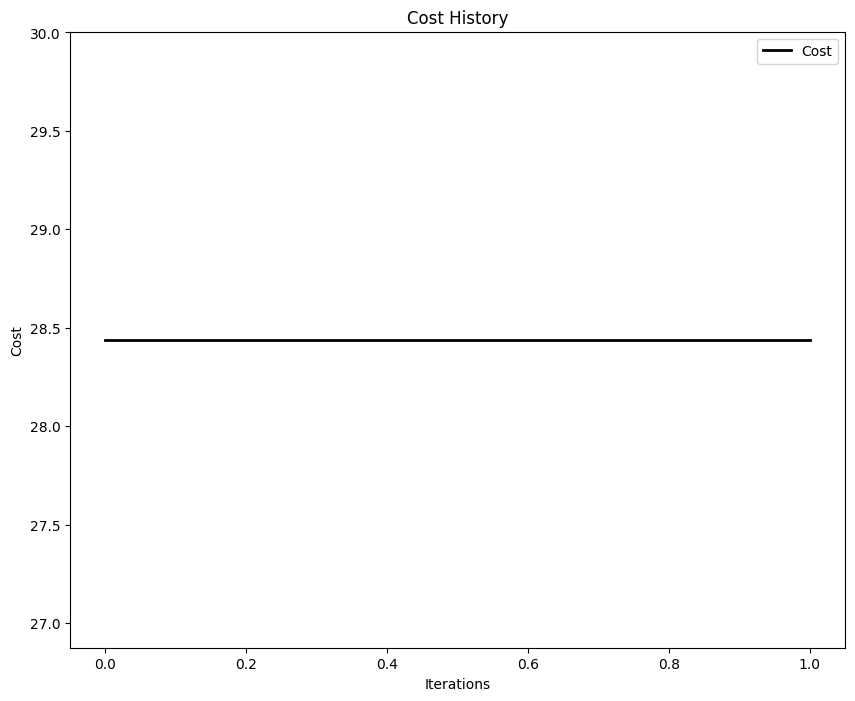

<Figure size 640x480 with 0 Axes>

In [55]:
# Save scaling vector
scaling_vector_df = pd.DataFrame({'group_id': np.arange(len(best_pos)), 'scaling_factor': best_pos})
scaling_vector_df.to_csv(build_path([RUN_OUTPUT_DIR, f"scaling_vector_{unique_id}.csv"]), index=False)

# Save the reordered dictionary to a JSON file
# Convert arrays to lists
serializable_dict = {k: v.tolist() for k, v in reordered_dict.items()}

# Save to JSON file
with open(build_path([RUN_OUTPUT_DIR, f"reordered_dict_{unique_id}.json"]), 'w') as json_file:
    json.dump(serializable_dict, json_file, indent=2)

# log the best_solution len and the serializable_dict len
logging.info(f"Best solution length: {len(best_pos)}")
logging.info(f"Reordered dictionary keys length: {len(serializable_dict.keys())}")

# Plot the cost history
plot_cost_history(optimizer.cost_history)
plt.show()
plt.savefig(build_path([RUN_OUTPUT_DIR, f"cost_history_{unique_id}.png"]))